# Frontier Exploration

Objective: Implement a frontier exploration algorithm to decide where to travel in a map.

Map Representation: Use a Stochastic Occupancy grid to keep track of the states that are known vs. unknown, and occupied vs. unoccupied.

- When a state in the grid is within the sensing radius, the state is known.
- When the state is known, it is assigned a probability value of whether there is obstacle in that grid cell
- Probabilities range between 0 and 1. Here we use the heuristic that a cell is considered occupied if the probability of occupancy is greater than or equal to 0.5.
- If a cell is unknown, (has not been sensed), then the value of the cell is -1

<img src="i/f2.png" width=800>


In [1]:
from utils import *
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

### Exploration Heuristics

With a given Stochastic Occupancy map, we want to decide what states to
explore to balance gathering new information (traveling to unknown states), while remaining in regions
where we don’t believe there are any obstacles (traveling to unoccupied states). 

To balance these two things, we will look for states that satisfy the following conditions:

- The percentage of unknown cells surrounding a cell in some window should be greater than or equal
to 20% of the surrounding cells.

- The number of known, occupied cells surrounding a cell in some window should be 0.

- The percentage of known, unoccupied cells surrounding a cell in some window should be greater than
or equal to 30% of the surrounding cells.

Cells that satisfy these three heuristics will be considered valid cells to explore the frontier. 

A visualization of an example for defining these windows is shown in Figure 3. 

Note that the heuristics in the simple example shown in Figure 3 are different from the heuristics listed in the problem statement.

<img src="i/f3.png" width=1200>


## Define the Stochastic Occupancy Grid Class

- See class `StochOccupancyGrid2D` inside `utils.py`

## Define the Ground Truth Map with Obstascles

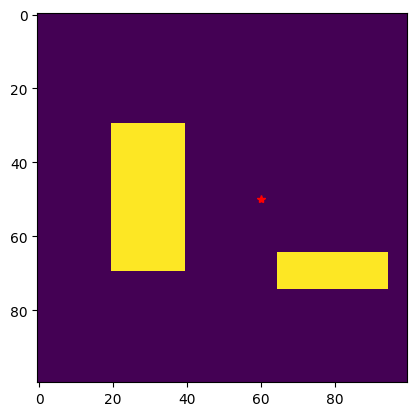

In [17]:
def define_map(grid_size=[10, 10], 
               state=[6., 5.], 
               obstacles=[[3, 5, 2, 4], [8, 7, 3, 1]], 
               resolution=0.1, 
               wsize=7):
    
    state = np.array(state)
    grid_size = (np.array(grid_size) / resolution).astype(int)

    occupancy_gt = -np.ones((int(grid_size[1]), int(grid_size[0])))
    obstacles = np.array(obstacles)
    obstacles_idxs =  [obstacle/resolution for obstacle in obstacles]
    for obstacles_idx in obstacles_idxs:
        occupancy_gt[int(obstacles_idx[1]-obstacles_idx[3]/2.) : int(obstacles_idx[1]+obstacles_idx[3]/2.), 
                    int(obstacles_idx[0]-obstacles_idx[2]/2.) : int(obstacles_idx[0]+obstacles_idx[2]/2.)] = 1.0

    
    show_center = np.array([3, 5]) / resolution
    show_occupancy_navigator(occupancy_gt, window_size=wsize, init_center=show_center)

    _, ax = plt.subplots(1)
    ax.imshow(occupancy_gt, origin='upper')
    ax.plot(state[0]/resolution, state[1]/resolution, 'r*')
    plt.show()

    return grid_size, resolution, occupancy_gt, state, obstacles_idxs

map_grid_size, resolution, occupancy_gt, current_state, obstacles_idxs = define_map()

## Define the Stochastic Occupancy grid of obstacles detected by the robot

In [23]:
def init_occupancy_probs(occupancy_gt, grid_size=map_grid_size, res=resolution, state=current_state, sensing_radius=3.0):
    observed_bounds = [(state - sensing_radius)/res, (state + sensing_radius)/res]
    occupancy_probs = -np.ones((grid_size[1], grid_size[0]))

    for x_idx in range(int(observed_bounds[0][0]), int(observed_bounds[1][0]), 1):
        for y_idx in range(int(observed_bounds[0][1]), int(observed_bounds[1][1]), 1):
            if np.linalg.norm(np.array([x_idx*res, y_idx*res]) - state) < sensing_radius:
                if occupancy_gt[y_idx, x_idx] < 0.0:
                    occupancy_probs[y_idx, x_idx] = 0.0
                else:
                    occupancy_probs[y_idx, x_idx] = 0.8

    return occupancy_probs


occupancy_probs = init_occupancy_probs(occupancy_gt)
show_center = np.array([3, 5]) / resolution
show_occupancy_navigator(occupancy_probs, window_size=7, init_center=show_center)

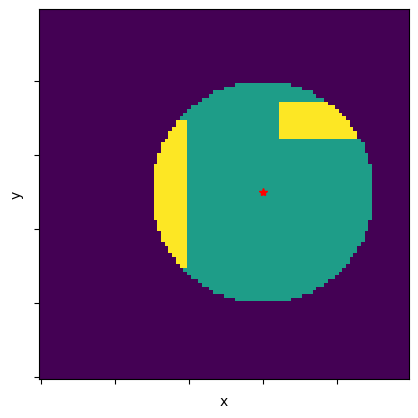

In [24]:
# Create Stochastic Occupancy grid
occupancy = StochOccupancyGrid2D(resolution=resolution,
        size_xy=map_grid_size,
        origin_xy=np.zeros((2,)),
        window_size=7,
        probs=occupancy_probs,
        thresh=0.5)

# Plot Stochastic Occupancy grid
fig,ax = plt.subplots(1)
ax.imshow(occupancy.probs, origin='lower')
ax.plot(current_state[0]/resolution, current_state[1]/resolution, 'r*')
ax.set_ylabel('y')
ax.set_xlabel('x')
ax.set_yticklabels([])
ax.set_xticklabels([])
plt.show()


## Frontier Exploration within robot's Stochastic Occupancy map

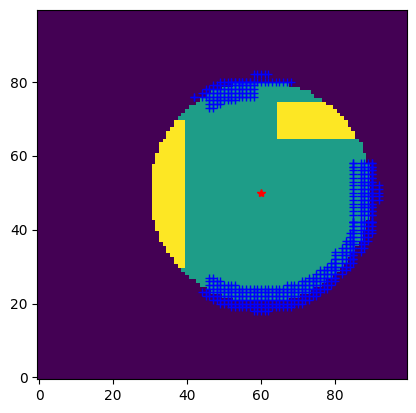

In [34]:
# Write the explore function in the notebook according to these heuristics and return the resulting plot, 
# showing the robot’s Stochastic Occupancy Map and the cells that satisfy the exploration heuristic.

def explore(occupancy, window_size = 13, occupied_threshhold=0, unknown_threshold=0.2, free_threshold = 0.3):
    """ returns potential states to explore
    Args:
        occupancy (StochasticOccupancyGrid2D): Represents the known, unknown, occupied, and unoccupied states. See class in utils.py

    Returns:
        frontier_states (np.ndarray): state-vectors in (x, y) coordinates of potential states to explore. Shape is (N, 2), 
        where N is the number of possible states to explore.

    HINTS:
    - Function `convolve2d` may be helpful in producing the number of unknown, and number of occupied states in a window of a specified cell
    - Note the distinction between physical states and grid cells. Most operations can be done on grid cells, and converted to 
        physical states at the end of the function with `occupancy.grid2state()`
    """

    # window_size defines the window side-length for neighborhood of cells to consider for heuristics
    ########################### Code starts here ###########################

    probs = occupancy.probs
    convolution_filter = np.ones([window_size, window_size])
    
    occupied_cells = (probs >= 0.5).astype(float)
    free_cells = ((probs >= 0) & (probs < 0.5)).astype(float)
    unknown_cells = (probs == -1).astype(float)

    # Use convolution to compute the number of occupied, free, and unknown cells in the neighborhood of each cell
    occupied_count = convolve2d(occupied_cells, convolution_filter, 'same')
    free_count = convolve2d(free_cells, convolution_filter, 'same')
    unknown_count = convolve2d(unknown_cells, convolution_filter, 'same')

    W = window_size**2    
    unknown_threshold = unknown_threshold*W
    free_threshold = free_threshold*W

    frontier_mask = (
        (unknown_count >= unknown_threshold)
        & (free_count >= free_threshold)
        & (occupied_count == occupied_threshhold)
    )
    row_idx, col_idx = np.where(frontier_mask)
    frontier_grid = np.column_stack((col_idx, row_idx))
    frontier_states = occupancy.grid2state(frontier_grid)

    dist = np.min(np.linalg.norm(current_state - frontier_states, axis = 1))
    idx = np.argmin(np.linalg.norm(current_state - frontier_states, axis = 1))
    ########################### Code ends here ###########################
    return frontier_states, dist, idx

# Call to explore function
state_xy, dist, idx = explore(occupancy)
grid_xy = occupancy.state2grid(state_xy)

# Plot Stochastic Occupancy grid with frontier to explore
fig,ax = plt.subplots(1)
ax.imshow(occupancy.probs, origin='lower')
ax.plot(current_state[0]/resolution, current_state[1]/resolution, 'r*')
ax.plot(grid_xy[:,0], grid_xy[:,1], 'b+')
plt.show()